In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [6]:
df=pd.read_excel("Data/Online Retail.xlsx")

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [11]:
df['Sales']=df['Quantity']*df['UnitPrice']

In [12]:
df['Sales'].head()

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: Sales, dtype: float64

In [13]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [14]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [15]:
print(df.shape)

(530104, 9)


In [16]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [17]:
daily_sales=df.groupby(df['InvoiceDate'].dt.date)['Sales'].sum().reset_index()

In [18]:
daily_sales.head()

,InvoiceDate,Sales
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46


In [19]:
daily_sales['InvoiceDate']=pd.to_datetime(daily_sales['InvoiceDate'])

In [20]:
daily_sales['year']=daily_sales['InvoiceDate'].dt.year

In [21]:
daily_sales['month']=daily_sales['InvoiceDate'].dt.month

In [22]:
daily_sales['day']=daily_sales['InvoiceDate'].dt.day

In [23]:
daily_sales['dayofweek']=daily_sales['InvoiceDate'].dt.dayofweek

In [24]:
daily_sales.head()

,InvoiceDate,Sales,year,month,day,dayofweek
0,2010-12-01,58960.79,2010,12,1,2
1,2010-12-02,47748.38,2010,12,2,3
2,2010-12-03,46943.71,2010,12,3,4
3,2010-12-05,31774.95,2010,12,5,6
4,2010-12-06,54830.46,2010,12,6,0


In [25]:
daily_sales['Lag1'] = daily_sales['Sales'].shift(1)
daily_sales['Lag7'] = daily_sales['Sales'].shift(7)
daily_sales['Rolling7'] = daily_sales['Sales'].rolling(7).mean() #Average sales over the last 7 days

In [26]:
daily_sales = daily_sales.dropna()

In [27]:
len(daily_sales)

298

In [28]:
x = daily_sales[
    ['year',
     'month',
     'day',
     'dayofweek',
     'Lag1',
     'Lag7',
     'Rolling7']
]

y = daily_sales['Sales']

In [29]:
print(len(x))
print(len(y))

298
298


In [30]:
#train test split
split_index=int(len(daily_sales)*0.8)

x_train=x[:split_index]
x_test=x[split_index:]

y_train=y[:split_index]
y_test=y[split_index:]

In [31]:
print(len(x_test))
print(len(y_test))

60
60


In [32]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [33]:
predictions = model.predict(x_test)

In [34]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 13129.991204666669
R2 Score: 0.19258246681180546


In [35]:
print(len(y_test))
print(len(predictions))

60
60


In [36]:
print(daily_sales['Sales'].describe())

count       298.000000
mean      34501.402933
std       20915.188025
min        3457.110000
25%       22104.612500
50%       29164.720000
75%       44578.887500
max      200920.600000
Name: Sales, dtype: float64


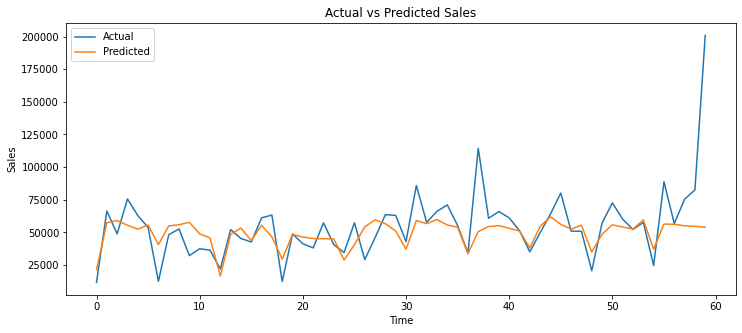

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Time')
plt.ylabel('Sales')

plt.legend()
plt.show()

In [38]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
6   Rolling7    0.430597
3  dayofweek    0.195620
5       Lag7    0.106878
2        day    0.103024
4       Lag1    0.093549
1      month    0.062683
0       year    0.007648


In [40]:
#linear Regression model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)


In [46]:
from sklearn.metrics import r2_score,mean_absolute_error

rscore=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("r2score:",rscore)
print("mae of Linear Regression:",mae)

r2score: 0.4763913654987634
mae of Linear Regression: 12676.393070334867


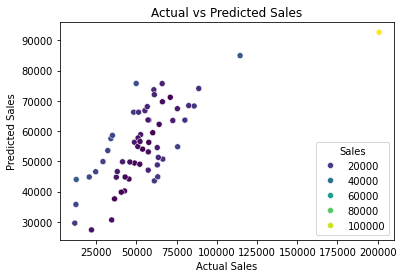

In [53]:
import seaborn as sns
error=abs(y_test-y_pred)
sns.scatterplot(x=y_test,y=y_pred,hue=error,palette='viridis')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()